In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
df.shape

(569, 31)

In [5]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='str')

In [6]:
data.target_names

array(['malignant', 'benign'], dtype='<U9')

In [7]:
X = df.drop(columns='target')
y = df['target']

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y #keeps the ratio of each claass (target)
)

In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)
pred = model.predict(X_test)

In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [11]:
print("Accuracy: ", accuracy_score(y_test, pred))
print("Precision: ", precision_score(y_test, pred))
print("Recall: ", recall_score(y_test, pred))
print("F1: ", f1_score(y_test, pred))

Accuracy:  0.9649122807017544
Precision:  0.9594594594594594
Recall:  0.9861111111111112
F1:  0.9726027397260274


In [12]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, pred)

array([[39,  3],
       [ 1, 71]])

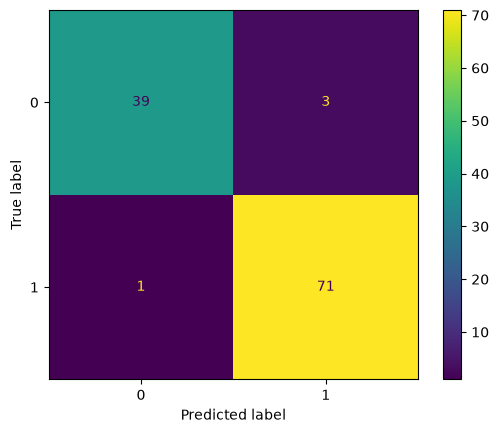

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred
)

In [24]:
print("Manual Calculations")
print("Accuracy: ", ((39+71)/(39+3+1+71) * 100))
print("Precision: ", (71/(71+3) * 100))
print("Recall: ", (71/(71+1) * 100))

Manual Calculations
Accuracy:  96.49122807017544
Precision:  95.94594594594594
Recall:  98.61111111111111


In [15]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    pred,
    target_names=data.target_names)
)

              precision    recall  f1-score   support

   malignant       0.97      0.93      0.95        42
      benign       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



Support displays the actual number of each class.

precision_score and recall_score in scikit-learn sees 1 as a positive class as default. That means, recall_score sees how well the model found 'benign'. In the medical situation, we want to see how well the model finds 'malignant'.

In [27]:
print(accuracy_score(y_test, pred))
print(precision_score(y_test, pred, pos_label=0))
print(recall_score(y_test, pred, pos_label=0))
print(f1_score(y_test, pred, pos_label=0))

0.9649122807017544
0.975
0.9285714285714286
0.9512195121951219


In [25]:
print("Manual Calculations")
print("Accuracy: ", ((39+71)/(39+3+1+71) * 100))
print("Precision: ", (39/(39+1) * 100))
print("Recall: ", (39/(39+3) * 100))

Manual Calculations
Accuracy:  96.49122807017544
Precision:  97.5
Recall:  92.85714285714286


Positive doesn't always mean something good or '1'. The important thing is what we define the class we are interested in as.

In [20]:
results = X_test.copy()

results["actual"] = y_test
results["predicted"] = pred

results.head(10)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,actual,predicted
256,19.550,28.77,133.60,1207.0,0.09260,0.20630,0.17840,0.11440,0.1893,0.06232,...,178.60,1926.0,0.1281,0.53290,0.42510,0.19410,0.2818,0.10050,0,0
428,11.130,16.62,70.47,381.1,0.08151,0.03834,0.01369,0.01370,0.1511,0.06148,...,74.35,421.1,0.1030,0.06219,0.04580,0.04044,0.2383,0.07083,1,1
501,13.820,24.49,92.33,595.9,0.11620,0.16810,0.13570,0.06759,0.2275,0.07237,...,106.00,788.0,0.1794,0.39660,0.33810,0.15210,0.3651,0.11830,0,0
363,16.500,18.29,106.60,838.1,0.09686,0.08468,0.05862,0.04835,0.1495,0.05593,...,117.20,1009.0,0.1338,0.16790,0.16630,0.09123,0.2394,0.06469,1,1
564,21.560,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,166.10,2027.0,0.1410,0.21130,0.41070,0.22160,0.2060,0.07115,0,0
464,13.170,18.22,84.28,537.3,0.07466,0.05994,0.04859,0.02870,0.1454,0.05549,...,95.10,687.6,0.1282,0.19650,0.18760,0.10450,0.2235,0.06925,1,1
358,8.878,15.49,56.74,241.0,0.08293,0.07698,0.04721,0.02381,0.1930,0.06621,...,65.27,302.0,0.1015,0.12480,0.09441,0.04762,0.2434,0.07431,1,1
343,19.680,21.68,129.90,1194.0,0.09797,0.13390,0.18630,0.11030,0.2082,0.05715,...,157.60,1540.0,0.1218,0.34580,0.47340,0.22550,0.4045,0.07918,0,0
516,18.310,20.58,120.80,1052.0,0.10680,0.12480,0.15690,0.09451,0.1860,0.05941,...,142.20,1493.0,0.1492,0.25360,0.37590,0.15100,0.3074,0.07863,0,0
567,20.600,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,184.60,1821.0,0.1650,0.86810,0.93870,0.26500,0.4087,0.12400,0,0


In [23]:
wrong_predictions = results[
    results["actual"] != results["predicted"]
]

wrong_predictions

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,actual,predicted
541,14.47,24.99,95.81,656.4,0.08837,0.12300,0.10090,0.03890,0.1872,0.06341,...,113.50,808.9,0.1340,0.4202,0.4040,0.1205,0.3187,0.10230,1,0
41,10.95,21.35,71.90,371.1,0.12270,0.12180,0.10440,0.05669,0.1895,0.06870,...,87.22,514.0,0.1909,0.2698,0.4023,0.1424,0.2964,0.09606,0,1
73,13.80,15.79,90.43,584.1,0.10070,0.12800,0.07789,0.05069,0.1662,0.06566,...,110.30,812.4,0.1411,0.3542,0.2779,0.1383,0.2589,0.10300,0,1
385,14.60,23.29,93.97,664.7,0.08682,0.06636,0.08390,0.05271,0.1627,0.05416,...,102.20,758.2,0.1312,0.1581,0.2675,0.1359,0.2477,0.06836,0,1


* Precision = How precise are my positive predictions?
* Recall = How many of the actual positives did I retrieve(recall)?

In medical situation, recall is important because it can be a big problem if we miss an actual malignant patient.

1. What does accuracy measure?
- Accuracy measures the percentage of correct predictions.

2. Why can accuracy be misleading?
- Accuracy can be misleading when the classes are imbalanced because a model can achieve high accuracy simply by predicting the majority class.

3. What is precision?
- Precision measures how many predicted positives are actually positive.

4. What is recall?
- Recall measures how many actual positives the model correctly identifies.

5. What does F1 score measure?
- F1 score balances precision and recall.